# Steganalysis Benchmark — IWT 3-Channel Steganography on ALASKA#2

Ported from the BossBase version. Cover images are the **uncompressed color PPM** release (512×512) from https://alaska.utt.fr/#material, so there is no JPEG-compression confound in the metrics.

## Cell 1 — Imports & Global Configuration

In [1]:
import os
import sys
import glob
import random
import warnings
import itertools
from pathlib import Path
from copy import deepcopy

warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
from scipy.stats import chisquare, ttest_ind
from scipy.signal import convolve2d
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_curve, auc, accuracy_score,
    confusion_matrix, classification_report,
    roc_auc_score
)
from tabulate import tabulate
from tqdm import tqdm

sys.path.insert(0, "/teamspace/studios/this_studio")
import IWT_FAST_3CHANNEL as IWT_FAST_MOD

# ─────────────────────────────────────────────────────────────────────────────
# Experimental configuration — all tunable parameters in one place
# ─────────────────────────────────────────────────────────────────────────────

CFG = {
    # Dataset — ALASKA#2 uncompressed color covers (PPM, 512x512)
    # Source: https://alaska.utt.fr/#material  ("Uncompressed COLOR images
    # datasets" -> "Size 512x512, PPM"). No JPEG in the pipeline, so PSNR/
    # SSIM/chi-square/RS/SRM results are not confounded by compression noise.
    "alaska2_dir":   "/teamspace/studios/this_studio/alaska2_raw_color_512/",
    "output_dir":    "/teamspace/studios/this_studio/Next-Gen-Encryption-Steganography/steganalysis_results",
    "dataset_name":  "ALASKA#2 (uncompressed color)",
    "image_res":     "512×512",
    "color_space":   "Native RGB (uncompressed PPM)",

    # Experiment scale
    "max_images":    100,       # set higher for a full run
    "payload_rates": [0.1, 0.2, 0.4],   # bits per pixel
    "n_trials":      10,         # independent random splits per payload rate

    # Classifier
    "n_folds":       5,          # stratified k-fold within each trial
    "svm_C":         0.01,       # LinearSVC regularisation (FLD approximation)
    "test_size":     0.3,        # fraction held out per trial

    # SRM
    "srm_T":         4,          # co-occurrence truncation

    # Reproducibility
    "seed":          42,
}

for d in [CFG["output_dir"], os.path.join(CFG["output_dir"], "stego_temp")]:
    os.makedirs(d, exist_ok=True)

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])

print("Configuration:")
for k, v in CFG.items():
    print(f"  {k:<20}: {v}")


Configuration:
  alaska2_dir         : /teamspace/studios/this_studio/alaska2_raw_color_512/
  output_dir          : /teamspace/studios/this_studio/Next-Gen-Encryption-Steganography/steganalysis_results
  dataset_name        : ALASKA#2 (uncompressed color)
  image_res           : 512×512
  color_space         : Native RGB (uncompressed PPM)
  max_images          : 100
  payload_rates       : [0.1, 0.2, 0.4]
  n_trials            : 10
  n_folds             : 5
  svm_C               : 0.01
  test_size           : 0.3
  srm_T               : 4
  seed                : 42


## Cell 2 — Load ALASKA#2 (uncompressed color covers)

In [2]:
def load_alaska2(directory: str, max_images: int) -> list:
    """
    Loads ALASKA#2 uncompressed color cover images (PPM, 512x512) from the
    UTT 'Material' release. Images are already 3-channel color, so — unlike
    BossBase — no grayscale-to-BGR conversion is needed. There is also no
    JPEG compression anywhere in this source, so covers are artifact-free.
    """
    paths = sorted(glob.glob(os.path.join(directory, "*.tif")))
    if not paths:
        raise FileNotFoundError(f"No .tif files in {directory}")
    paths = paths[:max_images]

    images = []
    for p in tqdm(paths, desc="Loading ALASKA#2"):
        bgr = cv2.imread(p, cv2.IMREAD_COLOR)   # cv2 reads TIFF natively -> BGR
        if bgr is None:
            continue
        images.append((p, bgr))

    print(f"\nLoaded {len(images)} images")
    print(f"  Shape : {images[0][1].shape}  dtype={images[0][1].dtype}")
    print(f"  Range : [{images[0][1].min()}, {images[0][1].max()}]")
    return images


cover_images = load_alaska2(CFG["alaska2_dir"], CFG["max_images"])
N_IMAGES = len(cover_images)


Loading ALASKA#2: 100%|██████████| 100/100 [00:00<00:00, 298.29it/s]


Loaded 100 images
  Shape : (512, 512, 3)  dtype=uint8
  Range : [3, 251]


## Cell 3 — Capacity Analysis

In [3]:
def channel_capacity_bytes(img: np.ndarray) -> int:
    """
    Returns the maximum embeddable bytes for a given image using
    the 3-channel IWT scheme. Matches IWT_FAST.IWT.capacity_bytes().
    """
    iwt_tmp = IWT_FAST_MOD.IWT()
    return iwt_tmp.capacity_bytes(img)


def bpp_to_chars(img: np.ndarray, bpp: float) -> int:
    """Convert bits-per-pixel payload rate to embeddable character count."""
    h, w = img.shape[:2]
    total_bits  = int(h * w * bpp)
    usable_bits = max(0, total_bits - 64)    # 64-bit prefix overhead
    return usable_bits // 8


def make_random_ascii(n: int) -> str:
    """Random printable ASCII string of length n."""
    return ''.join(chr(random.randint(32, 126)) for _ in range(n))


# Print capacity report for one representative image
sample_iwt = IWT_FAST_MOD.IWT()
_, sample_img = cover_images[0]
print("=== Capacity Report (representative image) ===")
sample_iwt.capacity_report(sample_img)

cap_bytes  = [channel_capacity_bytes(img) for _, img in cover_images]
print(f"\nAcross {N_IMAGES} images:")
print(f"  Mean capacity : {np.mean(cap_bytes):,.0f} bytes")
print(f"  Min  capacity : {np.min(cap_bytes):,} bytes")
print(f"  Max  capacity : {np.max(cap_bytes):,} bytes")


=== Capacity Report (representative image) ===
Image size:           512×512 pixels
Blocks per channel:   4096  (64×64)
Bits per channel:     262,144  (32,768 bytes)
Total (3 channels):   786,432 bits  (98,304 bytes)
Usable capacity:      98,288 bytes  (prefix overhead deducted)

Across 100 images:
  Mean capacity : 98,288 bytes
  Min  capacity : 98,288 bytes
  Max  capacity : 98,288 bytes


## Cell 4 — Embedding Pipeline

In [4]:
def embed_single(
    cover_bgr: np.ndarray,
    message:   str,
    out_path:  str,
) -> np.ndarray:
    """
    Embeds message into cover_bgr using IWT_FAST 3-channel IWT steganography.
    Returns stego image as BGR uint8 array, or None on failure.
    """
    iwt = IWT_FAST_MOD.IWT()
    result = iwt.encode_image(cover_bgr.copy(), message, output_path=out_path)
    if result is False:
        return None
    return result


def verify_extraction(stego_bgr: np.ndarray, original_message: str) -> bool:
    """Decodes stego image and checks exact match with original message."""
    iwt = IWT_FAST_MOD.IWT()
    recovered = iwt.decode_image(stego_bgr)
    return recovered == original_message


# ── Embed all images at all payload rates ─────────────────────────────────────
# stego_bank[bpp] = list of dicts with keys: cover, stego, message, path, verified
stego_bank  = {bpp: [] for bpp in CFG["payload_rates"]}
embed_stats = {bpp: {"success": 0, "failed": 0, "verify_fail": 0}
               for bpp in CFG["payload_rates"]}

for bpp in CFG["payload_rates"]:
    print(f"\nEmbedding at {bpp} bpp ...")
    for src_path, cover in tqdm(cover_images, desc=f"bpp={bpp}"):
        n_chars = bpp_to_chars(cover, bpp)
        if n_chars < 1:
            embed_stats[bpp]["failed"] += 1
            continue

        message  = make_random_ascii(n_chars)
        out_path = os.path.join(
            CFG["output_dir"], "stego_temp",
            f"{Path(src_path).stem}_{bpp}.png"
        )
        stego = embed_single(cover, message, out_path)

        if stego is None:
            embed_stats[bpp]["failed"] += 1
            continue

        verified = verify_extraction(stego, message)
        if not verified:
            embed_stats[bpp]["verify_fail"] += 1

        stego_bank[bpp].append({
            "cover":    cover,
            "stego":    stego,
            "message":  message,
            "path":     out_path,
            "verified": verified,
            "n_chars":  n_chars,
            "bpp_actual": (n_chars * 8) / (cover.shape[0] * cover.shape[1]),
        })
        embed_stats[bpp]["success"] += 1

print("\n=== Embedding Summary ===")
for bpp in CFG["payload_rates"]:
    s = embed_stats[bpp]
    v = sum(1 for r in stego_bank[bpp] if r["verified"])
    print(f"  bpp={bpp}: {s['success']} embedded  |  "
          f"{s['failed']} failed  |  "
          f"{v}/{s['success']} extraction verified")



Embedding at 0.1 bpp ...


bpp=0.1: 100%|██████████| 100/100 [00:28<00:00,  3.47it/s]



Embedding at 0.2 bpp ...


bpp=0.2: 100%|██████████| 100/100 [00:41<00:00,  2.39it/s]



Embedding at 0.4 bpp ...


bpp=0.4: 100%|██████████| 100/100 [01:10<00:00,  1.43it/s]


=== Embedding Summary ===
  bpp=0.1: 100 embedded  |  0 failed  |  100/100 extraction verified
  bpp=0.2: 100 embedded  |  0 failed  |  100/100 extraction verified
  bpp=0.4: 100 embedded  |  0 failed  |  100/100 extraction verified


## Cell 5 — Image Quality Metrics (PSNR & SSIM)

+-----------------+--------------+---------------------+--------+-----------+----------------+
|   Payload (bpp) | PSNR (dB)    | SSIM                |    MAD |   Max |Δ| | Changed px %   |
+=================+==============+=====================+========+===========+================+
|             0.1 | 58.90 ± 8.03 | 0.999552 ± 0.002251 | 0.0367 |      58.4 | 2.07%          |
+-----------------+--------------+---------------------+--------+-----------+----------------+
|             0.2 | 55.70 ± 8.00 | 0.999304 ± 0.002600 | 0.0664 |      68.5 | 4.14%          |
+-----------------+--------------+---------------------+--------+-----------+----------------+
|             0.4 | 52.11 ± 8.27 | 0.998610 ± 0.004169 | 0.1298 |      88.7 | 8.28%          |
+-----------------+--------------+---------------------+--------+-----------+----------------+
Note: PSNR > 40 dB and SSIM > 0.999 are imperceptibility thresholds.


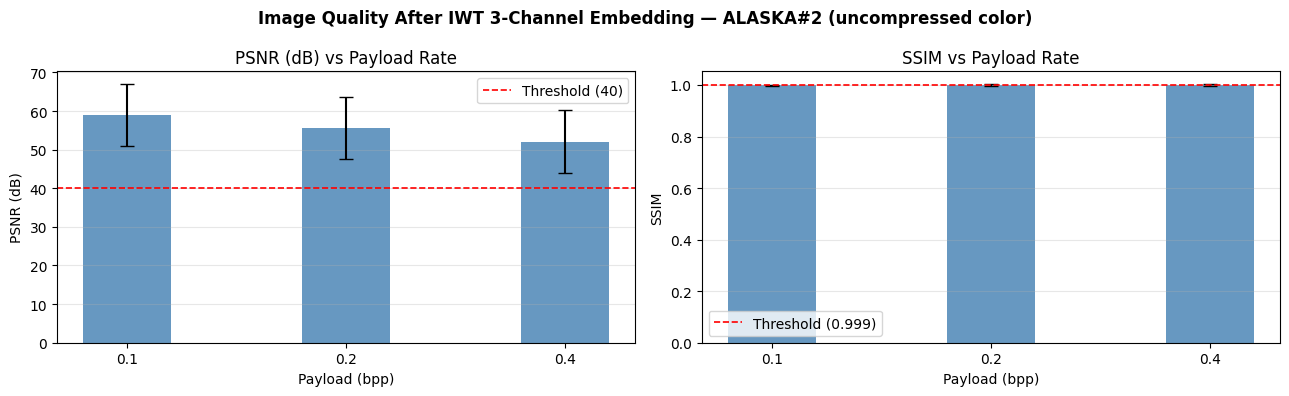

In [5]:
def compute_psnr(cover: np.ndarray, stego: np.ndarray) -> float:
    mse = np.mean((cover.astype(np.float64) - stego.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


def compute_ssim(cover: np.ndarray, stego: np.ndarray) -> float:
    """Full-image SSIM averaged over BGR channels."""
    c1, c2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2
    ssim_vals = []
    for ch in range(cover.shape[2]):
        a = cover[:, :, ch].astype(np.float64)
        b = stego[:, :, ch].astype(np.float64)
        mu_a, mu_b = a.mean(), b.mean()
        sig_a  = a.std() ** 2
        sig_b  = b.std() ** 2
        sig_ab = np.mean((a - mu_a) * (b - mu_b))
        num = (2 * mu_a * mu_b + c1) * (2 * sig_ab + c2)
        den = (mu_a**2 + mu_b**2 + c1) * (sig_a + sig_b + c2)
        ssim_vals.append(num / den)
    return float(np.mean(ssim_vals))


def pixel_difference_stats(cover: np.ndarray, stego: np.ndarray) -> dict:
    diff = (stego.astype(np.int32) - cover.astype(np.int32)).ravel()
    return {
        "mean_abs_diff": float(np.mean(np.abs(diff))),
        "max_abs_diff":  int(np.max(np.abs(diff))),
        "changed_pixels_pct": float(100 * np.sum(diff != 0) / len(diff)),
    }


quality_results = {}

for bpp in CFG["payload_rates"]:
    psnrs, ssims, diffs = [], [], []
    for rec in stego_bank[bpp]:
        psnrs.append(compute_psnr(rec["cover"], rec["stego"]))
        ssims.append(compute_ssim(rec["cover"], rec["stego"]))
        diffs.append(pixel_difference_stats(rec["cover"], rec["stego"]))

    quality_results[bpp] = {
        "psnr_mean":    np.mean(psnrs),    "psnr_std":  np.std(psnrs),
        "ssim_mean":    np.mean(ssims),    "ssim_std":  np.std(ssims),
        "mad_mean":     np.mean([d["mean_abs_diff"]      for d in diffs]),
        "max_diff_mean":np.mean([d["max_abs_diff"]       for d in diffs]),
        "changed_pct":  np.mean([d["changed_pixels_pct"] for d in diffs]),
    }

# Print table
rows = [[
    bpp,
    f"{r['psnr_mean']:.2f} ± {r['psnr_std']:.2f}",
    f"{r['ssim_mean']:.6f} ± {r['ssim_std']:.6f}",
    f"{r['mad_mean']:.4f}",
    f"{r['max_diff_mean']:.1f}",
    f"{r['changed_pct']:.2f}%",
] for bpp, r in quality_results.items()]

print(tabulate(
    rows,
    headers=["Payload (bpp)", "PSNR (dB)", "SSIM", "MAD", "Max |Δ|", "Changed px %"],
    tablefmt="grid"
))
print("Note: PSNR > 40 dB and SSIM > 0.999 are imperceptibility thresholds.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(CFG["payload_rates"]))
w = 0.4
for ax, metric, ylabel, ideal in zip(
    axes,
    [("psnr_mean", "psnr_std"), ("ssim_mean", "ssim_std")],
    ["PSNR (dB)", "SSIM"],
    [40, 0.999],
):
    means = [quality_results[b][metric[0]] for b in CFG["payload_rates"]]
    stds  = [quality_results[b][metric[1]] for b in CFG["payload_rates"]]
    ax.bar(x, means, w, yerr=stds, capsize=5, color="steelblue", alpha=0.82)
    ax.axhline(ideal, color="red", linestyle="--", linewidth=1.2, label=f"Threshold ({ideal})")
    ax.set_xticks(x); ax.set_xticklabels([str(b) for b in CFG["payload_rates"]])
    ax.set_xlabel("Payload (bpp)"); ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Payload Rate"); ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Image Quality After IWT 3-Channel Embedding — {CFG['dataset_name']}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "quality_metrics.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "quality_metrics.png"), dpi=200, bbox_inches="tight")
plt.show()


## Cell 6 — Chi-Square Attack

Chi² bpp=0.1:  85%|████████▌ | 85/100 [00:00<00:00, 163.46it/s]

Chi² bpp=0.4: 100%|██████████| 100/100 [00:00<00:00, 155.67it/s]


+-----------------+-----------------------+-----------------------+------------------+------------------+
|   Payload (bpp) | Cover χ² (mean±std)   | Stego χ² (mean±std)   |   Cover p (mean) |   Stego p (mean) |
+=================+=======================+=======================+==================+==================+
|             0.1 | 907.73 ± 1613.20      | 888.82 ± 1597.28      |            0.027 |           0.025  |
+-----------------+-----------------------+-----------------------+------------------+------------------+
|             0.2 | 907.73 ± 1613.20      | 870.96 ± 1581.87      |            0.027 |           0.0296 |
+-----------------+-----------------------+-----------------------+------------------+------------------+
|             0.4 | 907.73 ± 1613.20      | 850.05 ± 1557.74      |            0.027 |           0.0306 |
+-----------------+-----------------------+-----------------------+------------------+------------------+
Stego p ≈ 0 → chi-square attack detects embedd

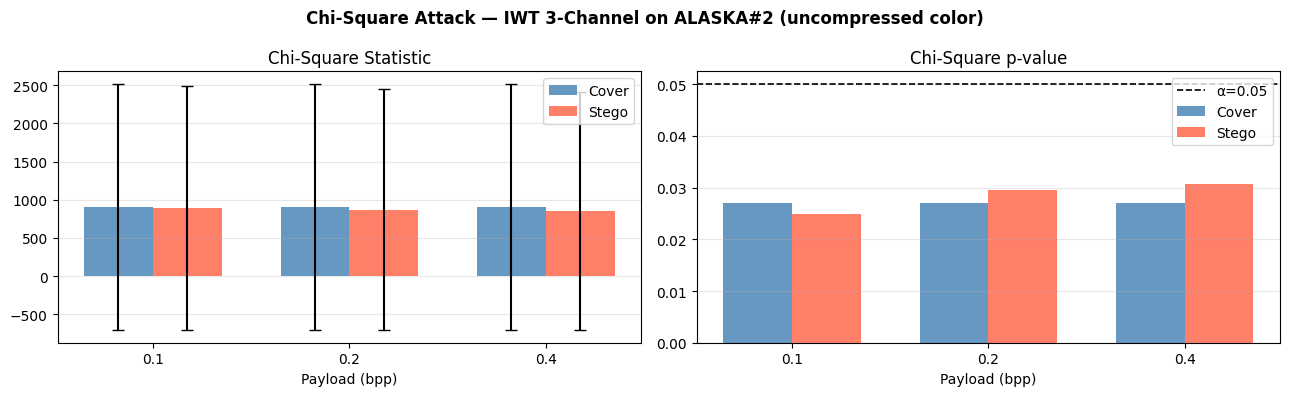

In [6]:
from scipy.stats import chi2 as chi2_dist  # for manual p-value computation

def chi_square_attack_per_channel(img: np.ndarray) -> dict:
    """
    Classical PoV chi-square attack (Westfeld & Pfitzmann 1999) applied to
    each BGR channel independently and averaged. Since IWT_FAST embeds across
    all 3 channels, all three are tested.

    NOTE: the statistic is computed manually (chi2 = sum((obs-exp)^2/exp),
    p = chi2.sf(stat, dof)) rather than via scipy.stats.chisquare. That
    function enforces sum(observed) == sum(expected), which does NOT hold
    here by construction: `observed` is the count of pixels at each *even*
    value, while `expected` is the *pair-average* of (even, odd) — these
    sums are not meant to match. On BossBase the mismatch happened to fall
    within scipy's default tolerance; on other datasets it can exceed it
    and raise ValueError, even though the underlying test is well-defined.
    """
    results = {}
    for ch_idx, ch_name in enumerate(["B", "G", "R"]):
        channel  = img[:, :, ch_idx].ravel().astype(np.uint8)
        hist     = np.bincount(channel, minlength=256).astype(float)
        observed, expected = [], []
        for k in range(0, 256, 2):
            pair_sum = hist[k] + hist[k + 1]
            if pair_sum > 0:
                observed.append(hist[k])
                expected.append(pair_sum / 2.0)
        obs = np.array(observed); exp = np.array(expected)
        mask = exp > 0
        obs, exp = obs[mask], exp[mask]

        stat = float(np.sum((obs - exp) ** 2 / exp))
        dof  = len(obs) - 1
        p    = float(chi2_dist.sf(stat, dof)) if dof > 0 else 1.0

        results[ch_name] = (stat, p)
    results["mean_stat"] = np.mean([v[0] for v in results.values() if isinstance(v, tuple)])
    results["min_p"]     = min(v[1] for v in results.values() if isinstance(v, tuple))
    return results


chi2_results = {}

for bpp in CFG["payload_rates"]:
    cover_stats, stego_stats = [], []
    for rec in tqdm(stego_bank[bpp], desc=f"Chi² bpp={bpp}"):
        cover_stats.append(chi_square_attack_per_channel(rec["cover"]))
        stego_stats.append(chi_square_attack_per_channel(rec["stego"]))

    chi2_results[bpp] = {
        "cover_stat_mean": np.mean([s["mean_stat"] for s in cover_stats]),
        "stego_stat_mean": np.mean([s["mean_stat"] for s in stego_stats]),
        "cover_p_mean":    np.mean([s["min_p"]     for s in cover_stats]),
        "stego_p_mean":    np.mean([s["min_p"]     for s in stego_stats]),
        "cover_stat_std":  np.std( [s["mean_stat"] for s in cover_stats]),
        "stego_stat_std":  np.std( [s["mean_stat"] for s in stego_stats]),
    }

rows = [[
    bpp,
    f"{r['cover_stat_mean']:.2f} ± {r['cover_stat_std']:.2f}",
    f"{r['stego_stat_mean']:.2f} ± {r['stego_stat_std']:.2f}",
    f"{r['cover_p_mean']:.4f}",
    f"{r['stego_p_mean']:.4f}",
] for bpp, r in chi2_results.items()]

print(tabulate(
    rows,
    headers=["Payload (bpp)", "Cover χ² (mean±std)", "Stego χ² (mean±std)",
             "Cover p (mean)", "Stego p (mean)"],
    tablefmt="grid"
))
print("Stego p ≈ 0 → chi-square attack detects embedding. p > 0.05 → not detected.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(CFG["payload_rates"]))
w = 0.35
labels = [str(b) for b in CFG["payload_rates"]]

ax = axes[0]
cover_stats_vals = [chi2_results[b]["cover_stat_mean"] for b in CFG["payload_rates"]]
stego_stats_vals = [chi2_results[b]["stego_stat_mean"] for b in CFG["payload_rates"]]
cover_stds = [chi2_results[b]["cover_stat_std"] for b in CFG["payload_rates"]]
stego_stds = [chi2_results[b]["stego_stat_std"] for b in CFG["payload_rates"]]
ax.bar(x - w/2, cover_stats_vals, w, yerr=cover_stds, label="Cover", color="steelblue", alpha=0.82, capsize=4)
ax.bar(x + w/2, stego_stats_vals, w, yerr=stego_stds, label="Stego", color="tomato",    alpha=0.82, capsize=4)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Chi-Square Statistic"); ax.set_xlabel("Payload (bpp)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(x - w/2, [chi2_results[b]["cover_p_mean"] for b in CFG["payload_rates"]],
       w, label="Cover", color="steelblue", alpha=0.82)
ax.bar(x + w/2, [chi2_results[b]["stego_p_mean"] for b in CFG["payload_rates"]],
       w, label="Stego", color="tomato", alpha=0.82)
ax.axhline(0.05, color="black", linestyle="--", linewidth=1.2, label="α=0.05")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Chi-Square p-value"); ax.set_xlabel("Payload (bpp)")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Chi-Square Attack — IWT 3-Channel on {CFG['dataset_name']}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "chi_square.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "chi_square.png"), dpi=200, bbox_inches="tight")
plt.show()


## Cell 7 — RS Analysis

RS bpp=0.4: 100%|██████████| 100/100 [18:40<00:00, 11.21s/it]


+-----------------+----------------------------+----------------------------+----------------------+
|   Payload (bpp) | RS Cover Est. (mean±std)   | RS Stego Est. (mean±std)   |   True Rate (bpp/ch) |
+=================+============================+============================+======================+
|             0.1 | 0.0083 ± 0.0345            | 0.0080 ± 0.0343            |               0.0333 |
+-----------------+----------------------------+----------------------------+----------------------+
|             0.2 | 0.0083 ± 0.0345            | 0.0080 ± 0.0349            |               0.0667 |
+-----------------+----------------------------+----------------------------+----------------------+
|             0.4 | 0.0083 ± 0.0345            | 0.0077 ± 0.0342            |               0.1333 |
+-----------------+----------------------------+----------------------------+----------------------+


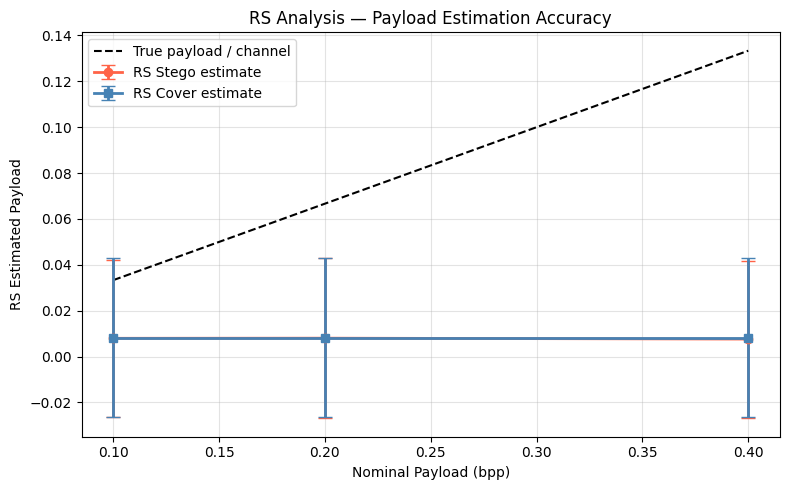

In [7]:
def rs_analysis(img: np.ndarray) -> dict:
    """
    RS steganalysis (Fridrich, Goljan & Du 2001).
    Applied to all 3 channels independently; results averaged.
    Returns estimated payload fraction and R/S group counts per channel.
    """
    def flip_fn(arr, mask):
        r = arr.copy().astype(np.int32)
        for idx in np.where(mask == 1)[0]:
            r[idx] = r[idx] + (1 if r[idx] % 2 == 0 else -1)
        return r

    def discriminant(group):
        return float(np.sum(np.abs(np.diff(group.astype(np.float64)))))

    mask     = np.array([0, 1, 0, 1])
    mask_neg = 1 - mask

    channel_ests = []
    for ch_idx in range(3):
        ch = img[:, :, ch_idx].astype(np.int32)
        R, S, R_neg, S_neg, total = 0, 0, 0, 0, 0
        for i in range(0, ch.shape[0] - 1, 2):
            for j in range(0, ch.shape[1] - 4 + 1, 4):
                g = ch[i, j:j+4]
                if len(g) < 4:
                    continue
                d0     = discriminant(g)
                d_f    = discriminant(flip_fn(g, mask))
                d_fn   = discriminant(flip_fn(g, mask_neg))
                if d_f  > d0: R     += 1
                if d_f  < d0: S     += 1
                if d_fn > d0: R_neg += 1
                if d_fn < d0: S_neg += 1
                total += 1

        denom = R - S + R_neg - S_neg
        est   = float(np.clip((R - R_neg) / denom, 0, 1)) if denom != 0 else 0.0
        channel_ests.append(est)

    return {
        "estimated_payload": float(np.mean(channel_ests)),
        "per_channel":       channel_ests,
    }


rs_results = {}

for bpp in CFG["payload_rates"]:
    cover_ests, stego_ests = [], []
    for rec in tqdm(stego_bank[bpp], desc=f"RS bpp={bpp}"):
        cover_ests.append(rs_analysis(rec["cover"])["estimated_payload"])
        stego_ests.append(rs_analysis(rec["stego"])["estimated_payload"])

    rs_results[bpp] = {
        "cover_mean": np.mean(cover_ests), "cover_std": np.std(cover_ests),
        "stego_mean": np.mean(stego_ests), "stego_std": np.std(stego_ests),
    }

rows = [[
    bpp,
    f"{r['cover_mean']:.4f} ± {r['cover_std']:.4f}",
    f"{r['stego_mean']:.4f} ± {r['stego_std']:.4f}",
    f"{bpp / 3:.4f}",   # bpp divided by 3 channels
] for bpp, r in rs_results.items()]

print(tabulate(
    rows,
    headers=["Payload (bpp)", "RS Cover Est. (mean±std)",
             "RS Stego Est. (mean±std)", "True Rate (bpp/ch)"],
    tablefmt="grid"
))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(CFG["payload_rates"],
        [bpp / 3 for bpp in CFG["payload_rates"]],
        "k--", linewidth=1.5, label="True payload / channel")
ax.errorbar(CFG["payload_rates"],
            [rs_results[b]["stego_mean"] for b in CFG["payload_rates"]],
            yerr=[rs_results[b]["stego_std"] for b in CFG["payload_rates"]],
            fmt="o-", color="tomato", linewidth=2, capsize=5, label="RS Stego estimate")
ax.errorbar(CFG["payload_rates"],
            [rs_results[b]["cover_mean"] for b in CFG["payload_rates"]],
            yerr=[rs_results[b]["cover_std"] for b in CFG["payload_rates"]],
            fmt="s-", color="steelblue", linewidth=2, capsize=5, label="RS Cover estimate")
ax.set_xlabel("Nominal Payload (bpp)"); ax.set_ylabel("RS Estimated Payload")
ax.set_title("RS Analysis — Payload Estimation Accuracy")
ax.legend(); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "rs_analysis.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "rs_analysis.png"), dpi=200, bbox_inches="tight")
plt.show()


## Cell 8 — SRM Feature Extraction

In [8]:
# # SRM filter bank — covers first-order, second-order, diagonal, Laplacian, and
# # edge-sensitive kernels across horizontal, vertical, and diagonal directions.
# # This is a practical subset of the full 34,671-feature SRM (Fridrich & Kodovsky 2012).
# # Each filter produces a 1D histogram + 2D horizontal co-occurrence matrix.

# SRM_KERNELS = {
#     # First-order
#     "h1_horiz":   np.array([[-1,  1]],             dtype=np.float64) / 1.0,
#     "h1_vert":    np.array([[-1], [1]],             dtype=np.float64) / 1.0,
#     # Second-order
#     "h2_horiz":   np.array([[1, -2,  1]],           dtype=np.float64) / 2.0,
#     "h2_vert":    np.array([[1], [-2], [1]],         dtype=np.float64) / 2.0,
#     "h2_diag":    np.array([[1, 0, 0], [0, -2, 0], [0, 0, 1]], dtype=np.float64) / 2.0,
#     "h2_adiag":   np.array([[0, 0, 1], [0, -2, 0], [1, 0, 0]], dtype=np.float64) / 2.0,
#     # Third-order
#     "h3_horiz":   np.array([[-1, 3, -3, 1]],        dtype=np.float64) / 3.0,
#     "h3_vert":    np.array([[-1], [3], [-3], [1]],   dtype=np.float64) / 3.0,
#     # Laplacian variants
#     "laplacian4": np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float64) / 4.0,
#     "laplacian8": np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]],    dtype=np.float64) / 8.0,
#     # 5×5 edge-sensitive
#     "edge5h":     np.array([[-1, 2, -2, 2, -1]],    dtype=np.float64) / 4.0,
#     "edge5v":     np.array([[-1], [2], [-2], [2], [-1]], dtype=np.float64) / 4.0,
# }


# def extract_srm_features(
#     img: np.ndarray,
#     T:   int = CFG["srm_T"],
# ) -> np.ndarray:
#     """
#     Extracts Spatial Rich Model (SRM) features from the embedding channel.
#     Since IWT_FAST embeds across all 3 channels, features are extracted from
#     all 3 and concatenated, giving the classifier visibility into each channel.

#     For each (channel, kernel) pair:
#       - Compute noise residual via convolution
#       - Quantise to integers in [-T, T]
#       - Build normalised 1D marginal histogram  (2T+1 bins)
#       - Build normalised 2D horizontal co-occurrence matrix  ((2T+1)^2 bins)
#       - Symmetrise: average (i,j) and (j,i) entries to reduce feature count

#     Total features: 3 channels × 12 kernels × [(2T+1) + (2T+1)^2 / 2 + 1] ≈ 3×12×45 = 1,620
#     """
#     features = []
#     bins     = 2 * T + 1

#     for ch_idx in range(3):
#         gray = img[:, :, ch_idx].astype(np.float64)
#         for kernel in SRM_KERNELS.values():
#             residual = convolve2d(gray, kernel, mode='same', boundary='symm')
#             residual = np.clip(np.round(residual), -T, T).astype(np.int32) + T  # shift to [0, 2T]

#             # 1D histogram
#             hist = np.bincount(residual.ravel().astype(np.uint32), minlength=bins).astype(np.float64)
#             hist /= hist.sum() + 1e-12
#             features.append(hist)

#             # 2D horizontal co-occurrence (symmetrised)
#             left  = residual[:, :-1].ravel()
#             right = residual[:, 1:].ravel()
#             co = np.zeros((bins, bins), dtype=np.float64)
#             np.add.at(co, (left, right), 1)
#             co /= co.sum() + 1e-12
#             # Symmetrize: C_sym[i,j] = (C[i,j] + C[j,i]) / 2
#             co_sym = (co + co.T) / 2.0
#             # Take upper triangle only (avoids redundancy)
#             features.append(co_sym[np.triu_indices(bins)])

#     return np.concatenate(features).astype(np.float32)


# # Extract features — this is the slowest step, cache results
# print("Extracting SRM features for all cover/stego pairs ...")
# print(f"Feature vector length: {extract_srm_features(cover_images[0][1]).shape[0]}")

# srm_cache = {}   # (bpp, idx, "cover"/"stego") → feature vector

# for bpp in CFG["payload_rates"]:
#     print(f"\n  bpp={bpp} ...")
#     for idx, rec in enumerate(tqdm(stego_bank[bpp])):
#         srm_cache[(bpp, idx, "cover")] = extract_srm_features(rec["cover"])
#         srm_cache[(bpp, idx, "stego")] = extract_srm_features(rec["stego"])

# print("\nFeature extraction complete.")


In [11]:
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------------------------------
# SRM filter bank — same kernels/values as before, now as torch tensors.
# --------------------------------------------------------------------------
SRM_KERNELS = {
    "h1_horiz":   np.array([[-1,  1]],             dtype=np.float64) / 1.0,
    "h1_vert":    np.array([[-1], [1]],             dtype=np.float64) / 1.0,
    "h2_horiz":   np.array([[1, -2,  1]],           dtype=np.float64) / 2.0,
    "h2_vert":    np.array([[1], [-2], [1]],         dtype=np.float64) / 2.0,
    "h2_diag":    np.array([[1, 0, 0], [0, -2, 0], [0, 0, 1]], dtype=np.float64) / 2.0,
    "h2_adiag":   np.array([[0, 0, 1], [0, -2, 0], [1, 0, 0]], dtype=np.float64) / 2.0,
    "h3_horiz":   np.array([[-1, 3, -3, 1]],        dtype=np.float64) / 3.0,
    "h3_vert":    np.array([[-1], [3], [-3], [1]],   dtype=np.float64) / 3.0,
    "laplacian4": np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float64) / 4.0,
    "laplacian8": np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]],    dtype=np.float64) / 8.0,
    "edge5h":     np.array([[-1, 2, -2, 2, -1]],    dtype=np.float64) / 4.0,
    "edge5v":     np.array([[-1], [2], [-2], [2], [-1]], dtype=np.float64) / 4.0,
}
KERNEL_NAMES = list(SRM_KERNELS.keys())
_KERNEL_TENSORS = {
    name: torch.tensor(k, dtype=torch.float32, device=DEVICE).unsqueeze(0).unsqueeze(0)
    for name, k in SRM_KERNELS.items()
}


def _pad_symmetric(x: torch.Tensor, pad: tuple) -> torch.Tensor:
    """Exact equivalent of scipy's boundary='symm' (edge pixel repeated)."""
    left, right, top, bottom = pad
    if left:
        x = torch.cat([x[:, :, :, :left].flip(-1), x], dim=-1)
    if right:
        x = torch.cat([x, x[:, :, :, -right:].flip(-1)], dim=-1)
    if top:
        x = torch.cat([x[:, :, :top, :].flip(-2), x], dim=-2)
    if bottom:
        x = torch.cat([x, x[:, :, -bottom:, :].flip(-2)], dim=-2)
    return x


def _conv_same(x: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
    kh, kw = kernel.shape[-2], kernel.shape[-1]
    pad_top = (kh - 1) // 2
    pad_bottom = kh - 1 - pad_top
    pad_left = (kw - 1) // 2
    pad_right = kw - 1 - pad_left
    x_padded = _pad_symmetric(x, (pad_left, pad_right, pad_top, pad_bottom))
    return F.conv2d(x_padded, kernel)


def _batched_bincount_1d(values: torch.Tensor, num_bins: int) -> torch.Tensor:
    B, L = values.shape
    offsets = (torch.arange(B, device=values.device) * num_bins).unsqueeze(1)
    flat = (values + offsets).reshape(-1)
    counts = torch.bincount(flat, minlength=B * num_bins)
    return counts.reshape(B, num_bins).to(torch.float32)


def _batched_bincount_2d(left: torch.Tensor, right: torch.Tensor, num_bins: int) -> torch.Tensor:
    B, L = left.shape
    idx = left * num_bins + right
    offsets = (torch.arange(B, device=left.device) * num_bins * num_bins).unsqueeze(1)
    flat = (idx + offsets).reshape(-1)
    counts = torch.bincount(flat, minlength=B * num_bins * num_bins)
    return counts.reshape(B, num_bins, num_bins).to(torch.float32)


_bins = 2 * CFG["srm_T"] + 1
_triu_i, _triu_j = torch.triu_indices(_bins, _bins, device=DEVICE)


def extract_srm_features_batch(imgs_np: np.ndarray, T: int = CFG["srm_T"]) -> np.ndarray:
    """
    GPU-batched SRM extraction. imgs_np: (N, H, W, 3) numpy array.
    Returns (N, feature_dim) float32 numpy array. Same math as the
    original per-image extract_srm_features, just vectorised over N,
    channels, and kernels.
    """
    imgs = torch.from_numpy(imgs_np).to(DEVICE, dtype=torch.float32)
    N, H, W, C = imgs.shape
    assert C == 3
    imgs = imgs.permute(0, 3, 1, 2).contiguous()  # (N,3,H,W)

    bins = 2 * T + 1
    all_feats = []

    with torch.no_grad():
        for ch in range(3):
            x = imgs[:, ch:ch + 1, :, :]
            for name in KERNEL_NAMES:
                kernel = _KERNEL_TENSORS[name]
                residual = _conv_same(x, kernel)
                residual = torch.clamp(torch.round(residual), -T, T).to(torch.int64) + T
                residual = residual.squeeze(1)  # (N,H,W)

                flat = residual.reshape(N, -1)
                hist = _batched_bincount_1d(flat, bins)
                hist = hist / (hist.sum(dim=1, keepdim=True) + 1e-12)

                left = residual[:, :, :-1].reshape(N, -1)
                right = residual[:, :, 1:].reshape(N, -1)
                co = _batched_bincount_2d(left, right, bins)
                co = co / (co.sum(dim=(1, 2), keepdim=True) + 1e-12)
                co_sym = (co + co.transpose(1, 2)) / 2.0
                co_triu = co_sym[:, _triu_i, _triu_j]

                all_feats.append(hist)
                all_feats.append(co_triu)

    return torch.cat(all_feats, dim=1).cpu().numpy().astype(np.float32)


# --------------------------------------------------------------------------
# Extract features — batched on GPU, cache results (same cache format as before)
# --------------------------------------------------------------------------
print("Extracting SRM features for all cover/stego pairs (CUDA batched) ...")

_feat_dim = 3 * len(KERNEL_NAMES) * (_bins + _triu_i.numel())
print(f"Feature vector length: {_feat_dim}")
print(f"Device: {DEVICE}")

BATCH_SIZE = 32  # tune to your GPU memory / image size

srm_cache = {}   # (bpp, idx, "cover"/"stego") → feature vector

for bpp in CFG["payload_rates"]:
    print(f"\n  bpp={bpp} ...")
    records = stego_bank[bpp]
    n = len(records)

    for start in tqdm(range(0, n, BATCH_SIZE)):
        end = min(start + BATCH_SIZE, n)
        chunk = records[start:end]

        cover_batch = np.stack([r["cover"] for r in chunk], axis=0)
        stego_batch = np.stack([r["stego"] for r in chunk], axis=0)

        cover_feats = extract_srm_features_batch(cover_batch)
        stego_feats = extract_srm_features_batch(stego_batch)

        for i, idx in enumerate(range(start, end)):
            srm_cache[(bpp, idx, "cover")] = cover_feats[i]
            srm_cache[(bpp, idx, "stego")] = stego_feats[i]

print("\nFeature extraction complete.")


Extracting SRM features for all cover/stego pairs (CUDA batched) ...
Feature vector length: 1944
Device: cuda

  bpp=0.1 ...


100%|██████████| 4/4 [00:02<00:00,  1.75it/s]



  bpp=0.2 ...


100%|██████████| 4/4 [00:02<00:00,  1.83it/s]



  bpp=0.4 ...


100%|██████████| 4/4 [00:02<00:00,  1.85it/s]


Feature extraction complete.


## Cell 9 — Multi-Trial Classifier with Full Statistical Reporting

In [12]:
def build_dataset(bpp: float) -> tuple:
    """Assembles X, y arrays from cached SRM features for a given payload rate."""
    X, y = [], []
    for idx in range(len(stego_bank[bpp])):
        X.append(srm_cache[(bpp, idx, "cover")]); y.append(0)
        X.append(srm_cache[(bpp, idx, "stego")]); y.append(1)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


def run_single_trial(
    X:      np.ndarray,
    y:      np.ndarray,
    seed:   int,
    C:      float = CFG["svm_C"],
    n_folds:int   = CFG["n_folds"],
) -> dict:
    """
    One complete trial: stratified k-fold cross-validation with LinearSVC.
    LinearSVC approximates Fisher Linear Discriminant (FLD), the standard
    classifier in SRM-based steganalysis (Fridrich & Kodovsky 2012).

    PE (probability of error) is defined as:
        PE = 0.5 × (FPR + FNR)   [balanced classes, so PE = 1 - accuracy for balanced split]

    Returns per-fold PE, AUC, accuracy; aggregated mean and std over folds;
    and combined ROC data across all folds.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    scaler = StandardScaler()

    fold_pe, fold_acc, fold_auc = [], [], []
    all_y_true, all_y_score     = [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr = scaler.fit_transform(X[train_idx])
        X_te = scaler.transform(X[test_idx])
        y_tr, y_te = y[train_idx], y[test_idx]

        clf = LinearSVC(max_iter=3000, C=C, random_state=seed)
        clf.fit(X_tr, y_tr)

        y_pred  = clf.predict(X_te)
        y_score = clf.decision_function(X_te)

        cm = confusion_matrix(y_te, y_pred)
        tn, fp, fn, tp = cm.ravel()
        fpr_v = fp / (fp + tn + 1e-12)
        fnr_v = fn / (fn + tp + 1e-12)
        pe    = 0.5 * (fpr_v + fnr_v)

        fold_pe.append(pe)
        fold_acc.append(accuracy_score(y_te, y_pred))
        all_y_true.extend(y_te)
        all_y_score.extend(y_score)

    fpr_arr, tpr_arr, _ = roc_curve(all_y_true, all_y_score)
    roc_auc = auc(fpr_arr, tpr_arr)

    return {
        "pe_mean":   np.mean(fold_pe),   "pe_std":  np.std(fold_pe),
        "acc_mean":  np.mean(fold_acc),  "acc_std": np.std(fold_acc),
        "auc":       roc_auc,
        "fpr":       fpr_arr,
        "tpr":       tpr_arr,
    }


# ── Run n_trials independent trials per payload rate ─────────────────────────
print(f"Running {CFG['n_trials']} trials × {CFG['n_folds']}-fold CV per payload rate ...\n")

trial_results = {bpp: [] for bpp in CFG["payload_rates"]}

for bpp in CFG["payload_rates"]:
    X, y = build_dataset(bpp)
    print(f"  bpp={bpp}  |  {X.shape[0]} samples  |  {X.shape[1]} features")
    for trial in tqdm(range(CFG["n_trials"]), desc=f"  Trials bpp={bpp}"):
        seed = CFG["seed"] + trial * 1000
        result = run_single_trial(X, y, seed=seed)
        trial_results[bpp].append(result)

# ── Aggregate across trials ───────────────────────────────────────────────────
aggregated = {}
for bpp in CFG["payload_rates"]:
    trials = trial_results[bpp]
    aggregated[bpp] = {
        "pe_mean":   np.mean([t["pe_mean"]  for t in trials]),
        "pe_std":    np.std( [t["pe_mean"]  for t in trials]),
        "acc_mean":  np.mean([t["acc_mean"] for t in trials]),
        "acc_std":   np.std( [t["acc_mean"] for t in trials]),
        "auc_mean":  np.mean([t["auc"]      for t in trials]),
        "auc_std":   np.std( [t["auc"]      for t in trials]),
    }

print("\n=== Classifier Results (mean ± std across trials) ===")
rows = [[
    bpp,
    f"{r['pe_mean']:.4f} ± {r['pe_std']:.4f}",
    f"{r['acc_mean']:.4f} ± {r['acc_std']:.4f}",
    f"{r['auc_mean']:.4f} ± {r['auc_std']:.4f}",
] for bpp, r in aggregated.items()]

print(tabulate(
    rows,
    headers=["Payload (bpp)", "PE (mean±std)", "Accuracy (mean±std)", "AUC (mean±std)"],
    tablefmt="grid"
))
print("\nPE ≈ 0.5, AUC ≈ 0.5 → detector at chance level → embedding is undetectable.")
print("PE ≈ 0.0, AUC ≈ 1.0 → detector reliably identifies stego → embedding is weak.")


Running 10 trials × 5-fold CV per payload rate ...

  bpp=0.1  |  200 samples  |  1944 features


  Trials bpp=0.1:   0%|          | 0/10 [00:00<?, ?it/s]

  Trials bpp=0.1: 100%|██████████| 10/10 [00:55<00:00,  5.53s/it]


  bpp=0.2  |  200 samples  |  1944 features


  Trials bpp=0.2: 100%|██████████| 10/10 [00:53<00:00,  5.34s/it]


  bpp=0.4  |  200 samples  |  1944 features


  Trials bpp=0.4: 100%|██████████| 10/10 [00:41<00:00,  4.14s/it]


=== Classifier Results (mean ± std across trials) ===
+-----------------+-----------------+-----------------------+------------------+
|   Payload (bpp) | PE (mean±std)   | Accuracy (mean±std)   | AUC (mean±std)   |
+=================+=================+=======================+==================+
|             0.1 | 0.7775 ± 0.0198 | 0.2225 ± 0.0198       | 0.1719 ± 0.0187  |
+-----------------+-----------------+-----------------------+------------------+
|             0.2 | 0.6585 ± 0.0127 | 0.3415 ± 0.0127       | 0.3462 ± 0.0192  |
+-----------------+-----------------+-----------------------+------------------+
|             0.4 | 0.4900 ± 0.0147 | 0.5100 ± 0.0147       | 0.5675 ± 0.0158  |
+-----------------+-----------------+-----------------------+------------------+

PE ≈ 0.5, AUC ≈ 0.5 → detector at chance level → embedding is undetectable.
PE ≈ 0.0, AUC ≈ 1.0 → detector reliably identifies stego → embedding is weak.


## Cell 10 — Publication-Quality ROC Curves

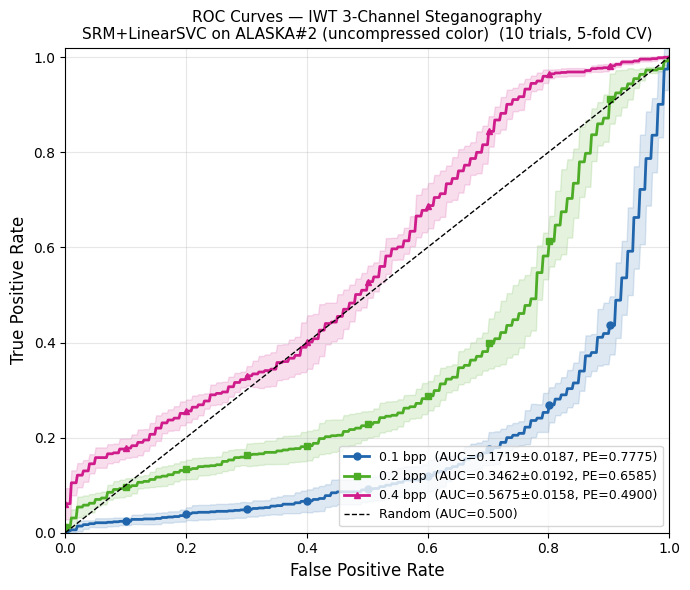

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
colors  = ["#2166ac", "#4dac26", "#d01c8b"]
markers = ["o", "s", "^"]

for (bpp, color, marker) in zip(CFG["payload_rates"], colors, markers):
    # Average ROC across trials via macro-interpolation
    # Interpolate each trial's TPR onto a common FPR grid
    base_fpr = np.linspace(0, 1, 500)
    tprs_interp = []
    for t in trial_results[bpp]:
        tprs_interp.append(np.interp(base_fpr, t["fpr"], t["tpr"]))
    mean_tpr = np.mean(tprs_interp, axis=0)
    std_tpr  = np.std(tprs_interp,  axis=0)
    mean_auc = aggregated[bpp]["auc_mean"]
    std_auc  = aggregated[bpp]["auc_std"]
    mean_pe  = aggregated[bpp]["pe_mean"]

    ax.plot(
        base_fpr, mean_tpr, color=color, linewidth=2, marker=marker,
        markevery=50, markersize=5,
        label=f"{bpp} bpp  (AUC={mean_auc:.4f}±{std_auc:.4f}, PE={mean_pe:.4f})"
    )
    ax.fill_between(base_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    alpha=0.15, color=color)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    "ROC Curves — IWT 3-Channel Steganography\n"
    f"SRM+LinearSVC on {CFG['dataset_name']}  ({CFG['n_trials']} trials, {CFG['n_folds']}-fold CV)",
    fontsize=11
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "roc_curves.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "roc_curves.png"), dpi=200, bbox_inches="tight")
plt.show()


## Cell 11 — Pixel Difference Distribution Plot

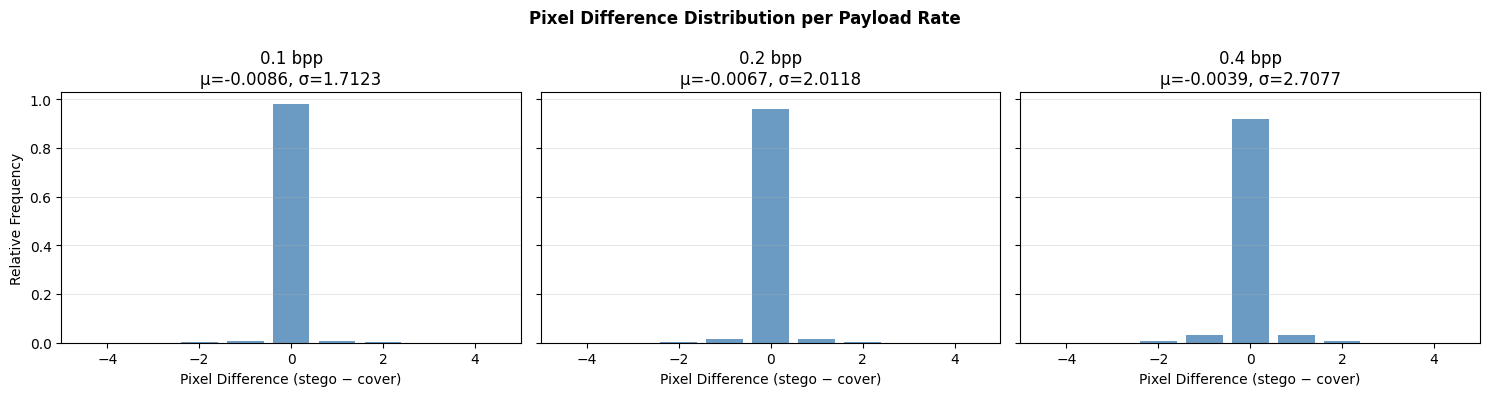

In [14]:
fig, axes = plt.subplots(1, len(CFG["payload_rates"]), figsize=(15, 4), sharey=True)

for ax, bpp in zip(axes, CFG["payload_rates"]):
    all_diffs = []
    for rec in stego_bank[bpp]:
        diff = (rec["stego"].astype(np.int32) - rec["cover"].astype(np.int32)).ravel()
        all_diffs.extend(diff.tolist())
    all_diffs = np.array(all_diffs)
    unique, counts = np.unique(all_diffs, return_counts=True)
    ax.bar(unique, counts / counts.sum(), color="steelblue", alpha=0.8)
    ax.set_title(f"{bpp} bpp\nμ={all_diffs.mean():.4f}, σ={all_diffs.std():.4f}")
    ax.set_xlabel("Pixel Difference (stego − cover)")
    ax.set_xlim(-5, 5)
    if ax == axes[0]:
        ax.set_ylabel("Relative Frequency")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Pixel Difference Distribution per Payload Rate", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "pixel_diff_distribution.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "pixel_diff_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()


## Cell 12 — Visual Distortion Inspection

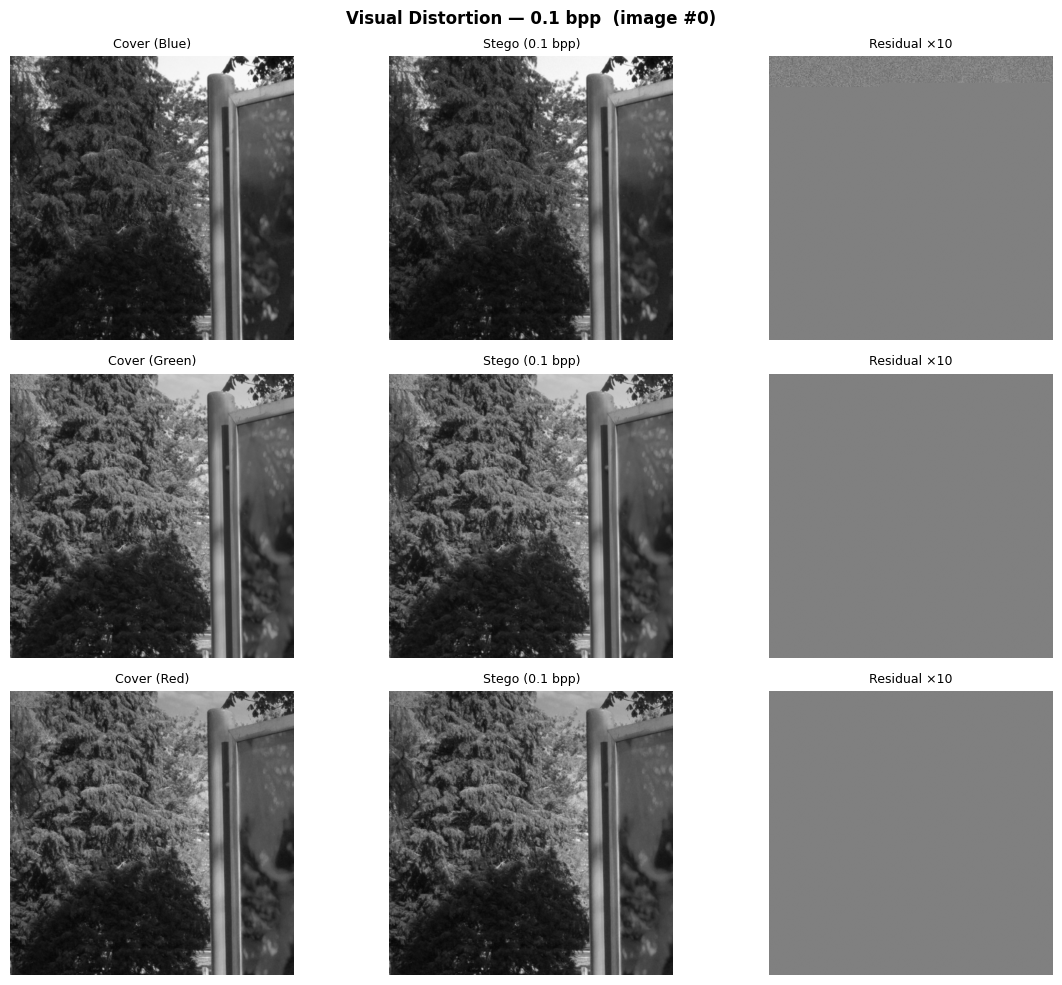

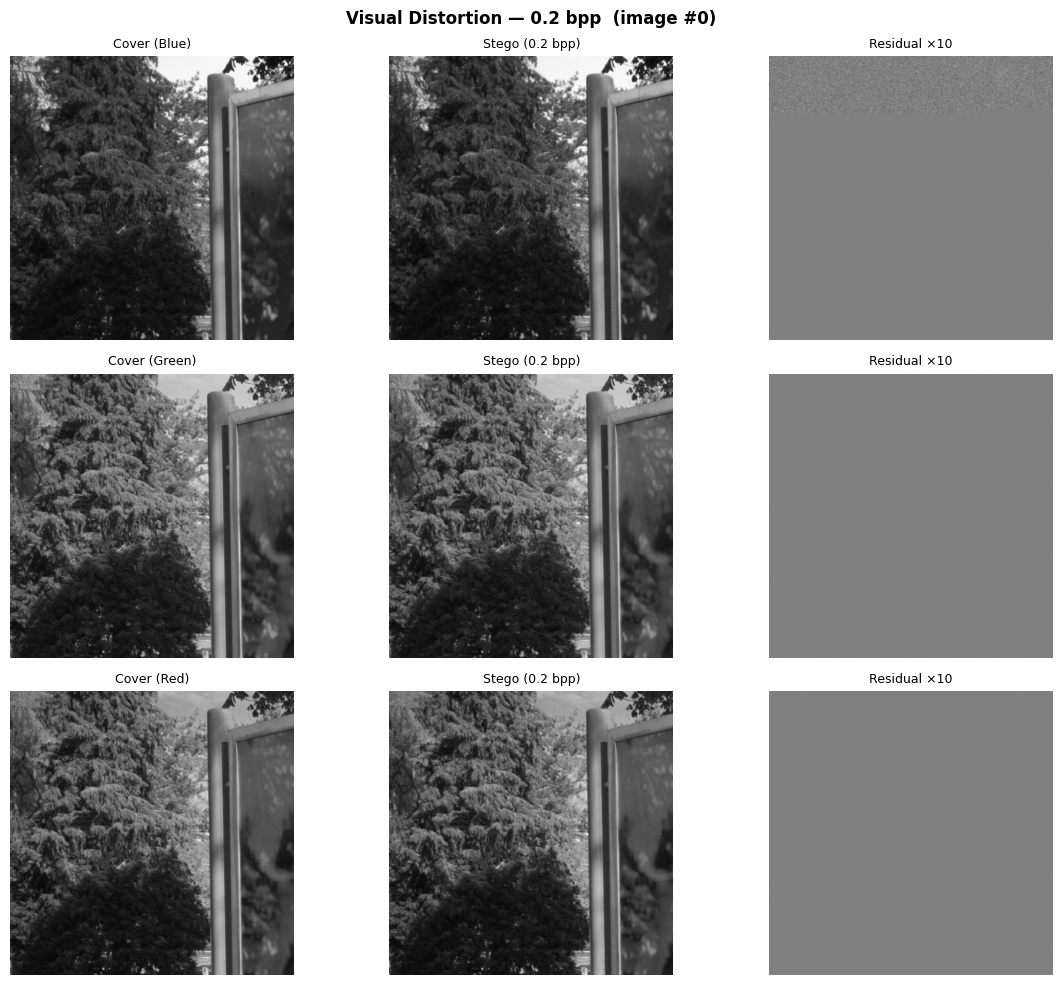

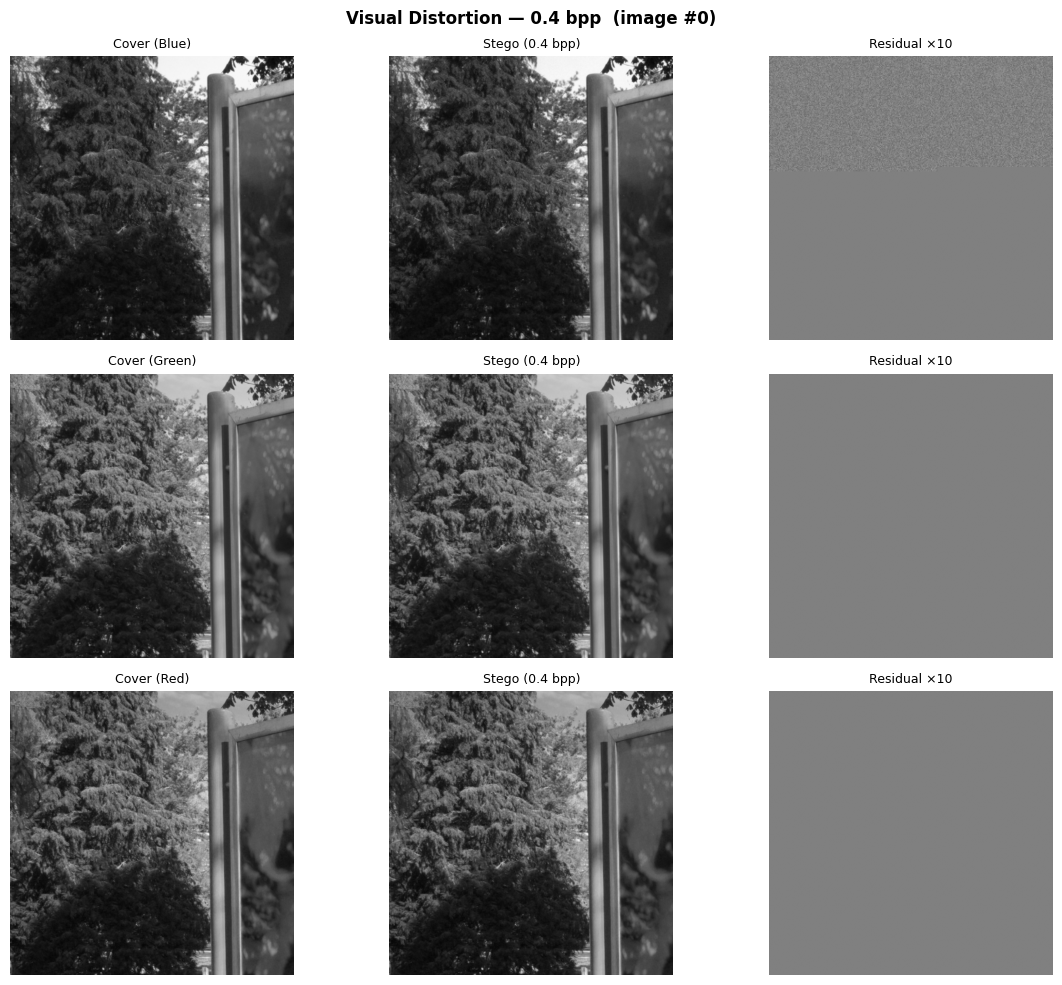

In [15]:
def plot_visual_comparison(
    cover: np.ndarray,
    stego: np.ndarray,
    bpp:   float,
    idx:   int = 0,
) -> None:
    """
    Side-by-side cover / stego / residual for each BGR channel.
    Residual is amplified ×10 and centred at 128 for visibility.
    """
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    ch_names = ["Blue", "Green", "Red"]

    for row, (ch_idx, ch_name) in enumerate(zip(range(3), ch_names)):
        cover_ch = cover[:, :, ch_idx]
        stego_ch = stego[:, :, ch_idx]
        residual = np.clip(
            (stego_ch.astype(np.int32) - cover_ch.astype(np.int32)) * 10 + 128, 0, 255
        ).astype(np.uint8)

        for col, (img_data, title) in enumerate(zip(
            [cover_ch, stego_ch, residual],
            [f"Cover ({ch_name})", f"Stego ({bpp} bpp)", "Residual ×10"],
        )):
            axes[row, col].imshow(img_data, cmap="gray", vmin=0, vmax=255)
            axes[row, col].set_title(title, fontsize=9)
            axes[row, col].axis("off")

    plt.suptitle(f"Visual Distortion — {bpp} bpp  (image #{idx})", fontweight="bold")
    plt.tight_layout()
    fname = os.path.join(CFG["output_dir"], f"visual_distortion_{bpp}bpp.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


for bpp in CFG["payload_rates"]:
    if stego_bank[bpp]:
        rec = stego_bank[bpp][0]
        plot_visual_comparison(rec["cover"], rec["stego"], bpp, idx=0)


## Cell 13 — Experimental Settings Table

In [16]:
def build_experimental_table() -> pd.DataFrame:
    """
    Produces a unified experimental-settings table suitable for direct
    inclusion in a paper. Columns follow standard steganalysis reporting:
    dataset, resolution, color space, payload size, embedding rate,
    samples per class, trials, and primary metric statistics.
    """
    rows = []
    for bpp in CFG["payload_rates"]:
        n_pairs    = len(stego_bank[bpp])
        n_chars    = bpp_to_chars(cover_images[0][1], bpp)
        payload_bits = n_chars * 8
        agg        = aggregated[bpp]

        rows.append({
            "Dataset":              CFG["dataset_name"],
            "Resolution":           CFG["image_res"],
            "Color Space":          CFG["color_space"],
            "Channels Embedded":    "B + G + R (3 / 3)",
            "Payload Size (bits)":  f"{payload_bits:,}",
            "Embedding Rate (bpp)": bpp,
            "Samples (per class)":  n_pairs,
            "Trials":               CFG["n_trials"],
            "CV Folds":             CFG["n_folds"],
            "PE (mean ± std)":      f"{agg['pe_mean']:.4f} ± {agg['pe_std']:.4f}",
            "Accuracy (mean ± std)":f"{agg['acc_mean']:.4f} ± {agg['acc_std']:.4f}",
            "AUC (mean ± std)":     f"{agg['auc_mean']:.4f} ± {agg['auc_std']:.4f}",
            "PSNR dB (mean ± std)": f"{quality_results[bpp]['psnr_mean']:.2f} ± {quality_results[bpp]['psnr_std']:.2f}",
            "SSIM (mean ± std)":    f"{quality_results[bpp]['ssim_mean']:.6f} ± {quality_results[bpp]['ssim_std']:.6f}",
        })

    return pd.DataFrame(rows)


exp_table = build_experimental_table()

print("\n" + "=" * 100)
print("UNIFIED EXPERIMENTAL SETTINGS AND RESULTS TABLE")
print("=" * 100)
print(tabulate(exp_table.T, tablefmt="grid"))

# Save as CSV for LaTeX import
csv_path = os.path.join(CFG["output_dir"], "experimental_table.csv")
exp_table.to_csv(csv_path, index=False)
print(f"\nSaved to {csv_path}")

# Save as LaTeX table
latex_path = os.path.join(CFG["output_dir"], "experimental_table.tex")
with open(latex_path, "w") as f:
    f.write(exp_table.to_latex(
        index=False,
        caption="Experimental settings and steganalysis results for IWT 3-channel steganography evaluated on " + CFG["dataset_name"] + ".",
        label="tab:experimental_results",
        escape=True,
    ))
print(f"LaTeX table saved to {latex_path}")



UNIFIED EXPERIMENTAL SETTINGS AND RESULTS TABLE
+-----------------------+-------------------------------+-------------------------------+-------------------------------+
| Dataset               | ALASKA#2 (uncompressed color) | ALASKA#2 (uncompressed color) | ALASKA#2 (uncompressed color) |
+-----------------------+-------------------------------+-------------------------------+-------------------------------+
| Resolution            | 512×512                       | 512×512                       | 512×512                       |
+-----------------------+-------------------------------+-------------------------------+-------------------------------+
| Color Space           | Native RGB (uncompressed PPM) | Native RGB (uncompressed PPM) | Native RGB (uncompressed PPM) |
+-----------------------+-------------------------------+-------------------------------+-------------------------------+
| Channels Embedded     | B + G + R (3 / 3)             | B + G + R (3 / 3)             | B + G +

## Cell 14 — Full Composite Results Figure (publication layout)

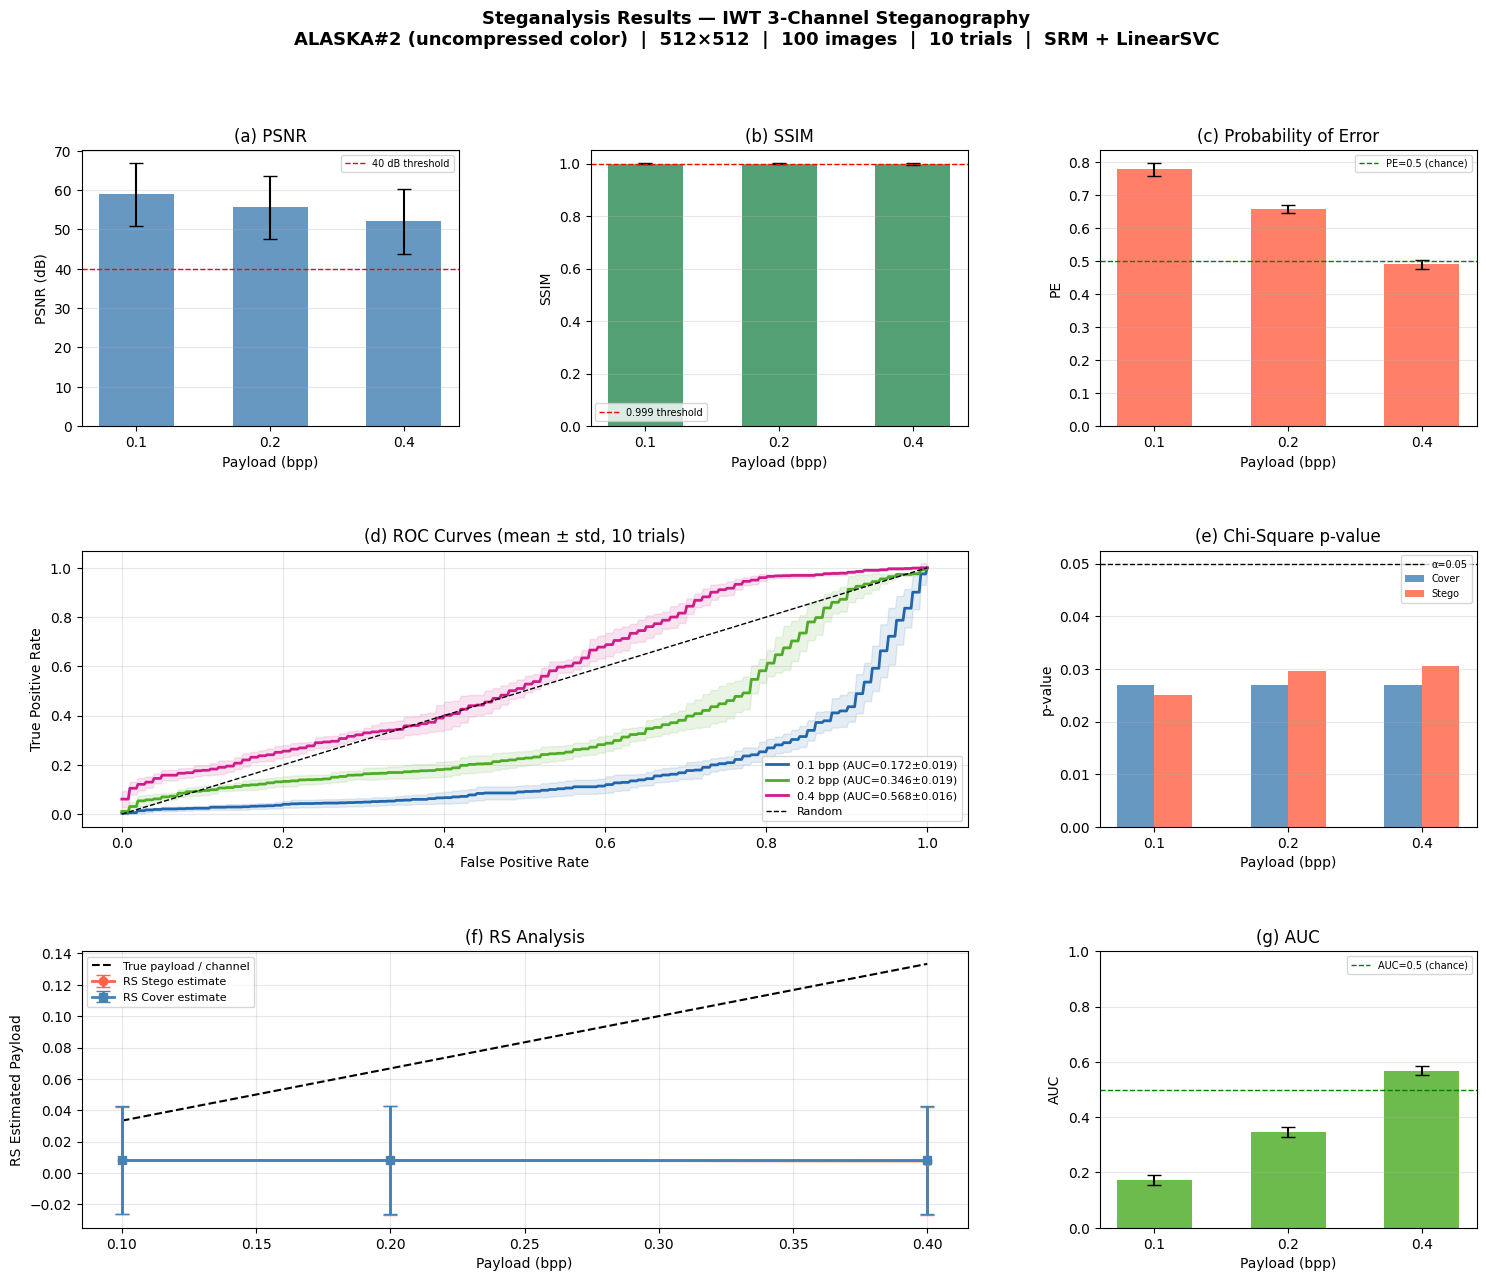

Composite figure saved (PDF + PNG).


In [17]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_bpp = {"0.1": "#2166ac", "0.2": "#4dac26", "0.4": "#d01c8b"}
labels_bpp = [str(b) for b in CFG["payload_rates"]]
x = np.arange(len(CFG["payload_rates"]))
w = 0.28

# ── (a) PSNR ────────────────────────────────────────────────────────────────
ax_psnr = fig.add_subplot(gs[0, 0])
means = [quality_results[b]["psnr_mean"] for b in CFG["payload_rates"]]
stds  = [quality_results[b]["psnr_std"]  for b in CFG["payload_rates"]]
ax_psnr.bar(x, means, w*2, yerr=stds, capsize=5, color="steelblue", alpha=0.82)
ax_psnr.axhline(40, color="red", linestyle="--", linewidth=1, label="40 dB threshold")
ax_psnr.set_xticks(x); ax_psnr.set_xticklabels(labels_bpp)
ax_psnr.set_xlabel("Payload (bpp)"); ax_psnr.set_ylabel("PSNR (dB)")
ax_psnr.set_title("(a) PSNR"); ax_psnr.legend(fontsize=7); ax_psnr.grid(axis="y", alpha=0.3)

# ── (b) SSIM ────────────────────────────────────────────────────────────────
ax_ssim = fig.add_subplot(gs[0, 1])
means = [quality_results[b]["ssim_mean"] for b in CFG["payload_rates"]]
stds  = [quality_results[b]["ssim_std"]  for b in CFG["payload_rates"]]
ax_ssim.bar(x, means, w*2, yerr=stds, capsize=5, color="seagreen", alpha=0.82)
ax_ssim.axhline(0.999, color="red", linestyle="--", linewidth=1, label="0.999 threshold")
ax_ssim.set_xticks(x); ax_ssim.set_xticklabels(labels_bpp)
ax_ssim.set_xlabel("Payload (bpp)"); ax_ssim.set_ylabel("SSIM")
ax_ssim.set_title("(b) SSIM"); ax_ssim.legend(fontsize=7); ax_ssim.grid(axis="y", alpha=0.3)

# ── (c) PE ───────────────────────────────────────────────────────────────────
ax_pe = fig.add_subplot(gs[0, 2])
means = [aggregated[b]["pe_mean"] for b in CFG["payload_rates"]]
stds  = [aggregated[b]["pe_std"]  for b in CFG["payload_rates"]]
ax_pe.bar(x, means, w*2, yerr=stds, capsize=5, color="tomato", alpha=0.82)
ax_pe.axhline(0.5, color="green", linestyle="--", linewidth=1, label="PE=0.5 (chance)")
ax_pe.set_xticks(x); ax_pe.set_xticklabels(labels_bpp)
ax_pe.set_xlabel("Payload (bpp)"); ax_pe.set_ylabel("PE")
ax_pe.set_title("(c) Probability of Error"); ax_pe.legend(fontsize=7); ax_pe.grid(axis="y", alpha=0.3)

# ── (d) ROC curves ───────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[1, :2])
base_fpr = np.linspace(0, 1, 500)
for bpp, color in zip(CFG["payload_rates"], ["#2166ac", "#4dac26", "#d01c8b"]):
    tprs_interp = [np.interp(base_fpr, t["fpr"], t["tpr"]) for t in trial_results[bpp]]
    mean_tpr = np.mean(tprs_interp, axis=0)
    std_tpr  = np.std(tprs_interp,  axis=0)
    agg      = aggregated[bpp]
    ax_roc.plot(base_fpr, mean_tpr, color=color, linewidth=2,
                label=f"{bpp} bpp (AUC={agg['auc_mean']:.3f}±{agg['auc_std']:.3f})")
    ax_roc.fill_between(base_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                        alpha=0.12, color=color)
ax_roc.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("(d) ROC Curves (mean ± std, 10 trials)")
ax_roc.legend(fontsize=8, loc="lower right"); ax_roc.grid(alpha=0.3)

# ── (e) Chi-square p-values ───────────────────────────────────────────────────
ax_chi = fig.add_subplot(gs[1, 2])
cover_ps = [chi2_results[b]["cover_p_mean"] for b in CFG["payload_rates"]]
stego_ps = [chi2_results[b]["stego_p_mean"] for b in CFG["payload_rates"]]
ax_chi.bar(x - w/2, cover_ps, w, label="Cover", color="steelblue", alpha=0.82)
ax_chi.bar(x + w/2, stego_ps, w, label="Stego", color="tomato",    alpha=0.82)
ax_chi.axhline(0.05, color="black", linestyle="--", linewidth=1, label="α=0.05")
ax_chi.set_xticks(x); ax_chi.set_xticklabels(labels_bpp)
ax_chi.set_xlabel("Payload (bpp)"); ax_chi.set_ylabel("p-value")
ax_chi.set_title("(e) Chi-Square p-value"); ax_chi.legend(fontsize=7); ax_chi.grid(axis="y", alpha=0.3)

# ── (f) RS Analysis ──────────────────────────────────────────────────────────
ax_rs = fig.add_subplot(gs[2, :2])
ax_rs.plot(CFG["payload_rates"],
           [b / 3 for b in CFG["payload_rates"]],
           "k--", linewidth=1.5, label="True payload / channel")
ax_rs.errorbar(CFG["payload_rates"],
               [rs_results[b]["stego_mean"] for b in CFG["payload_rates"]],
               yerr=[rs_results[b]["stego_std"]  for b in CFG["payload_rates"]],
               fmt="o-", color="tomato", capsize=5, linewidth=2, label="RS Stego estimate")
ax_rs.errorbar(CFG["payload_rates"],
               [rs_results[b]["cover_mean"] for b in CFG["payload_rates"]],
               yerr=[rs_results[b]["cover_std"]  for b in CFG["payload_rates"]],
               fmt="s-", color="steelblue", capsize=5, linewidth=2, label="RS Cover estimate")
ax_rs.set_xlabel("Payload (bpp)"); ax_rs.set_ylabel("RS Estimated Payload")
ax_rs.set_title("(f) RS Analysis"); ax_rs.legend(fontsize=8); ax_rs.grid(alpha=0.3)

# ── (g) AUC bar ──────────────────────────────────────────────────────────────
ax_auc = fig.add_subplot(gs[2, 2])
means = [aggregated[b]["auc_mean"] for b in CFG["payload_rates"]]
stds  = [aggregated[b]["auc_std"]  for b in CFG["payload_rates"]]
ax_auc.bar(x, means, w*2, yerr=stds, capsize=5, color="#4dac26", alpha=0.82)
ax_auc.axhline(0.5, color="green", linestyle="--", linewidth=1, label="AUC=0.5 (chance)")
ax_auc.set_xticks(x); ax_auc.set_xticklabels(labels_bpp)
ax_auc.set_xlabel("Payload (bpp)"); ax_auc.set_ylabel("AUC")
ax_auc.set_title("(g) AUC"); ax_auc.legend(fontsize=7); ax_auc.grid(axis="y", alpha=0.3)
ax_auc.set_ylim(0, 1)

plt.suptitle(
    f"Steganalysis Results — IWT 3-Channel Steganography\n"
    f"{CFG['dataset_name']}  |  {CFG['image_res']}  |  "
    f"{N_IMAGES} images  |  {CFG['n_trials']} trials  |  SRM + LinearSVC",
    fontsize=13, fontweight="bold"
)

plt.savefig(os.path.join(CFG["output_dir"], "composite_results.pdf"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(CFG["output_dir"], "composite_results.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Composite figure saved (PDF + PNG).")


## Cell 15 — Final Summary Print & File Index

In [18]:
print("\n" + "=" * 90)
print("STEGANALYSIS BENCHMARK COMPLETE")
print(f"Method  : IWT 3-Channel (Integer Haar Wavelet Transform, B+G+R embedding)")
print(f"Dataset : {CFG['dataset_name']}  |  {CFG['image_res']}  |  {N_IMAGES} images")
print(f"Trials  : {CFG['n_trials']}  |  CV Folds: {CFG['n_folds']}  |  Classifier: LinearSVC (FLD approx.)")
print("=" * 90)

print(tabulate(
    [[
        bpp,
        len(stego_bank[bpp]),
        f"{quality_results[bpp]['psnr_mean']:.2f} ± {quality_results[bpp]['psnr_std']:.2f}",
        f"{quality_results[bpp]['ssim_mean']:.6f} ± {quality_results[bpp]['ssim_std']:.6f}",
        f"{chi2_results[bpp]['stego_p_mean']:.4f}",
        f"{rs_results[bpp]['stego_mean']:.4f} ± {rs_results[bpp]['stego_std']:.4f}",
        f"{aggregated[bpp]['pe_mean']:.4f} ± {aggregated[bpp]['pe_std']:.4f}",
        f"{aggregated[bpp]['auc_mean']:.4f} ± {aggregated[bpp]['auc_std']:.4f}",
    ] for bpp in CFG["payload_rates"]],
    headers=["bpp", "Pairs", "PSNR (dB)", "SSIM",
             "χ² p (stego)", "RS Est. (stego)",
             "PE (mean±std)", "AUC (mean±std)"],
    tablefmt="grid"
))

print("\nOutput files:")
for fname in sorted(os.listdir(CFG["output_dir"])):
    fpath = os.path.join(CFG["output_dir"], fname)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<45} {size_kb:>8.1f} KB")



STEGANALYSIS BENCHMARK COMPLETE
Method  : IWT 3-Channel (Integer Haar Wavelet Transform, B+G+R embedding)
Dataset : ALASKA#2 (uncompressed color)  |  512×512  |  100 images
Trials  : 10  |  CV Folds: 5  |  Classifier: LinearSVC (FLD approx.)
+-------+---------+--------------+---------------------+----------------+-------------------+-----------------+------------------+
|   bpp |   Pairs | PSNR (dB)    | SSIM                |   χ² p (stego) | RS Est. (stego)   | PE (mean±std)   | AUC (mean±std)   |
+=======+=========+==============+=====================+================+===================+=================+==================+
|   0.1 |     100 | 58.90 ± 8.03 | 0.999552 ± 0.002251 |         0.025  | 0.0080 ± 0.0343   | 0.7775 ± 0.0198 | 0.1719 ± 0.0187  |
+-------+---------+--------------+---------------------+----------------+-------------------+-----------------+------------------+
|   0.2 |     100 | 55.70 ± 8.00 | 0.999304 ± 0.002600 |         0.0296 | 0.0080 ± 0.0349   | 0.6585 ±